## SVM Non-Linear

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

- The higher the dimension, the higher the likelihood of linear classification. However, the amount of computation and complexity increases.

- To solve this problem, ues the "Kernel".
  - Kernel :A low-dimensional vector arithmetic function, such as the result of a high-dimensional dot product operation.
  > $ K(x, x^{'}) = \phi(x)^{T} \phi (x^{'}) $

    - 1. Polynomial Kernel

    - 2. RBF Kernel(or Gaussian Kernel)

    - 3. Sigmoid Kernel

> min $_{w, b, \zeta} \frac{1}{2} ||w||^{2} + C \sum_{i=1}^{n} {\zeta_{i}} $

> subject $ y_{i}(w^{t} \phi( x_{i} + b) \geq 1 - \zeta_{i}  and  \zeta_{i} \geq 0 for 1 \leq i \leq n  $

Text(0, 0.5, 'Feature 2')

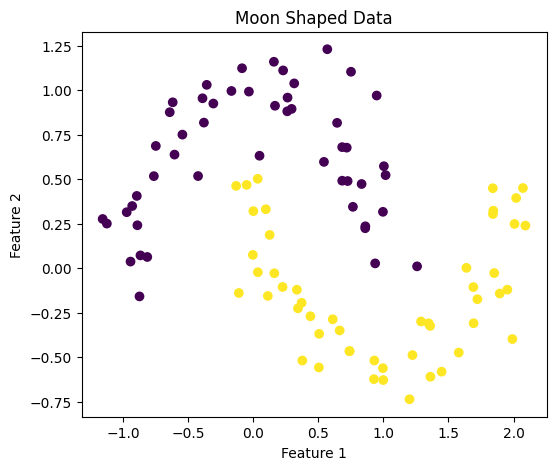

In [3]:
from sklearn.datasets import make_moons

# data
X_moons, y_moons = make_moons(n_samples=100,
                              noise=0.15,
                              random_state=0)

# plot
plt.figure(figsize=(6, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons)
plt.title("Moon Shaped Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")



In [7]:
def plot_svm(svm_model, X, y, title):
  svm_model.fit(X, y)
  plt.scatter(X[:, 0], X[:, 1],  c=y)

  plt.xlabel("feature 1")
  plt.ylabel("feature 2")

  plt.margins(0.2)

  xlim = plt.gca().get_xlim()
  ylim = plt.gca().get_ylim()

  xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 50),
                      np.linspace(ylim[0], ylim[1], 50))

  Z = svm_model.decision_function(np.column_stack((xx.ravel(), yy.ravel())))

  Z = Z.reshape(xx.shape)

  plt.contour(xx, yy, # in space(xx, yy)
                  Z, # plot Z
                  levels=[-1, 0, 1], # that z are -1, 0, 1
                  colors = ['orange', 'blue', 'orange'],
                  alpha=0.5,
                  linestyles=['--', '-', '--'])
  plt.title(title)


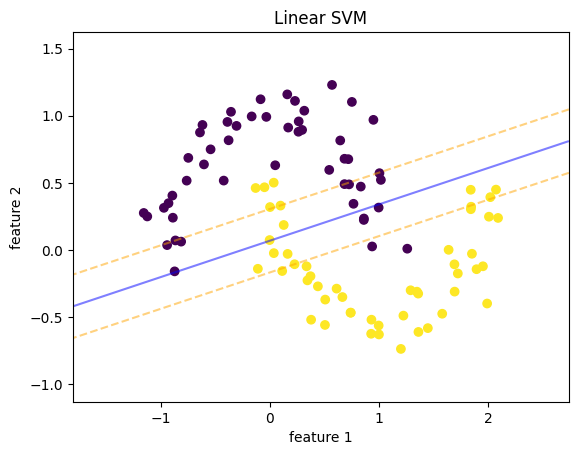

In [8]:
# SVM Linear
from sklearn.svm import SVC
linear_svm = SVC(kernel="linear", C=1000)
plot_svm(linear_svm, X_moons, y_moons, "Linear SVM")

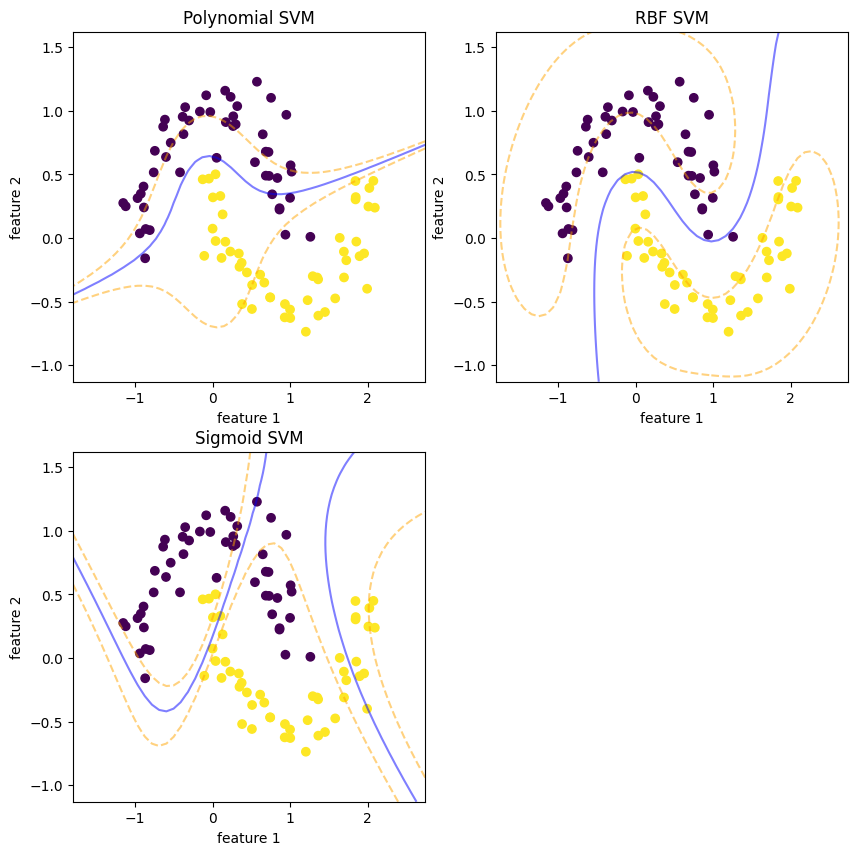

In [11]:
# SVM Non-Linear
poly_svm = SVC(kernel="poly", degree=3)
rbf_svm = SVC(kernel="rbf")
sigmoid_svm = SVC(kernel="sigmoid")

# plot
plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plot_svm(poly_svm, X_moons, y_moons, "Polynomial SVM")

plt.subplot(2, 2, 2)
plot_svm(rbf_svm, X_moons, y_moons, "RBF SVM")

plt.subplot(2, 2, 3)
plot_svm(sigmoid_svm, X_moons, y_moons, "Sigmoid SVM")
